In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the Dataset
df = pd.read_csv("Cardiotocographic.csv")
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


### Data Cleaning and Preparation

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


#### Missing Value Analysis

In [4]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

- If missing values are small in number, drop rows
- Otherwise, impute with mean/median depending on distribution

In [5]:
# For example, fill missing numeric with median
for col in df.columns:
    if df[col].isnull().sum() > 0:
        median = df[col].median()
        df[col].fillna(median, inplace=True)

C:\Users\Bibhuprasad Das\AppData\Local\Temp\ipykernel_22800\2742832927.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median, inplace=True)


In [6]:
df.nunique()

LB           153
AC          1068
FM           776
UC          1364
DL           822
DS           114
DP           264
ASTV         183
MSTV         165
ALTV         195
MLTV         351
Width        261
Tendency     111
NSP          111
dtype: int64

- From the unique value analysis, most variables contain many unique values, indicating that they behave as continuous numerical features.
- The NSP variable is the target variable representing fetal state classification, so it is treated separately and analyzed further to verify its valid categories.

In [8]:
df['NSP'].nunique()
df['NSP'].value_counts().head(10)

NSP
 1.000000    1567
 2.000000     280
 3.000000     164
-1.000000       5
 5.000000       4
 1.992959       1
 1.023060       1
 0.979280       1
 0.969447       1
 1.991339       1
Name: count, dtype: int64

The NSP column should contain only three categorical values (1, 2, 3). But, here additional unexpected values were observed. Therefore, we need to apply filtering to retain only valid classes.

In [9]:
# Keep only valid NSP values
df = df[df['NSP'].isin([1, 2, 3])]

# Convert to integer
df['NSP'] = df['NSP'].astype(int)

df['NSP'].value_counts()

NSP
1    1567
2     280
3     164
Name: count, dtype: int64

- After filtering invalid values, the NSP variable now contains only the valid classes (1, 2, and 3).
- These represent the fetal health states and will be used as the target variable for further analysis.

### Statistical Summary

In [10]:
# Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LB,2011.0,133.306557,11.192419,51.842487,126.000000,133.000000,140.000000,214.000000
AC,2011.0,0.003228,0.004377,-0.019284,0.000000,0.001634,0.005614,0.038567
FM,2011.0,0.010305,0.068027,-0.480634,0.000000,0.000000,0.002546,0.961268
UC,2011.0,0.004386,0.003362,-0.014925,0.001838,0.004478,0.006556,0.030002
DL,2011.0,0.001889,0.003270,-0.015393,0.000000,0.000000,0.003289,0.030769
DS,2011.0,0.000002,0.000142,-0.001353,0.000000,0.000000,0.000000,0.002706
DP,2011.0,0.000172,0.000806,-0.005348,0.000000,0.000000,0.000000,0.010695
ASTV,2011.0,46.865797,18.747841,-63.000000,32.000000,48.000000,61.000000,162.000000
MSTV,2011.0,1.367143,1.186527,-6.600000,0.700000,1.200000,1.700000,13.800000
ALTV,2011.0,10.336105,21.252327,-91.000000,0.000000,0.000000,11.000000,182.000000


In [11]:
# Statistical summary with mean, median, std, IQR
summary = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Std': df.std(),
    'IQR': df.quantile(0.75) - df.quantile(0.25)
})

print(summary)


                Mean      Median        Std        IQR
LB        133.306557  133.000000  11.192419  14.000000
AC          0.003228    0.001634   0.004377   0.005614
FM          0.010305    0.000000   0.068027   0.002546
UC          0.004386    0.004478   0.003362   0.004718
DL          0.001889    0.000000   0.003270   0.003289
DS          0.000002    0.000000   0.000142   0.000000
DP          0.000172    0.000000   0.000806   0.000000
ASTV       46.865797   48.000000  18.747841  29.000000
MSTV        1.367143    1.200000   1.186527   1.000000
ALTV       10.336105    0.000000  21.252327  11.000000
MLTV        8.328482    7.400000   7.721743   6.200000
Width      70.349027   67.000000  42.115133  63.000000
Tendency    0.306807    0.000000   0.643159   1.000000
NSP         1.302337    1.000000   0.611734   0.000000


##Interesting findings:

* Most variables have close mean and median values, showing fairly balanced data.
* ALTV is skewed, with many zeros but some large values.
* DS and DP show almost no variation (all zeros).
* Variables like Width and ASTV vary widely, shown by large std and IQR.
* NSP has no variation here, possibly a constant or categorical feature.

### Data Visualization

#### Outlier Detection (Visualization Only)

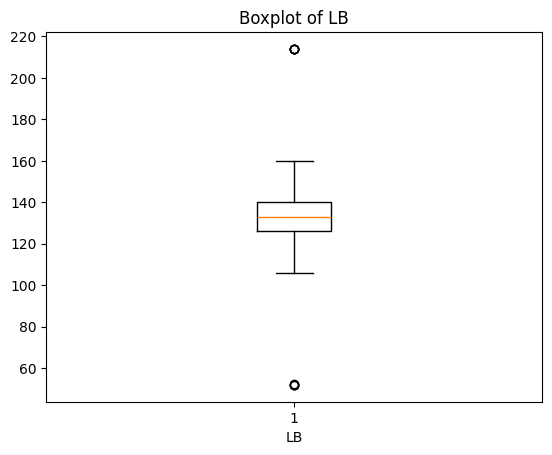

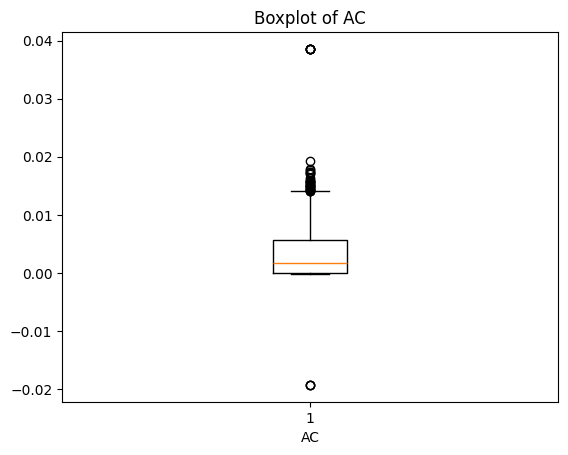

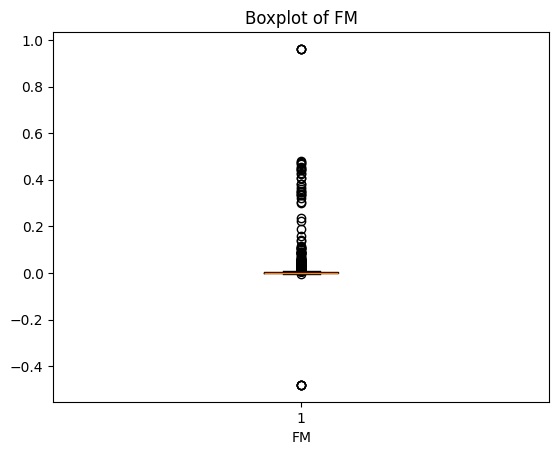

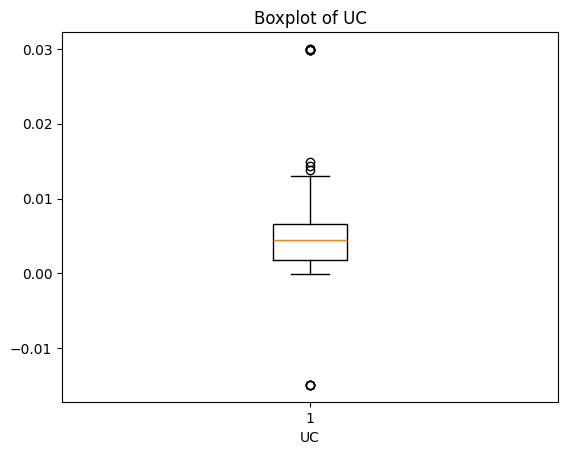

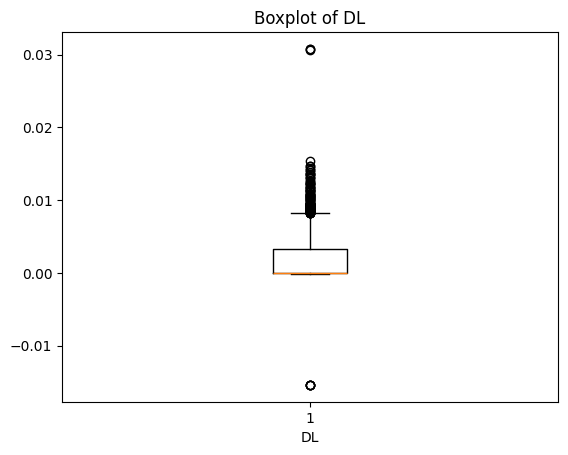

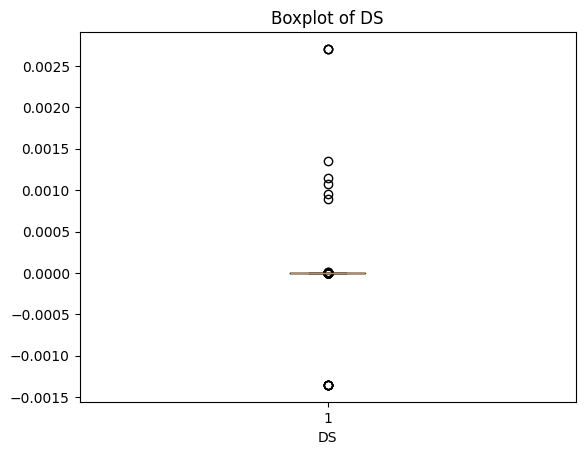

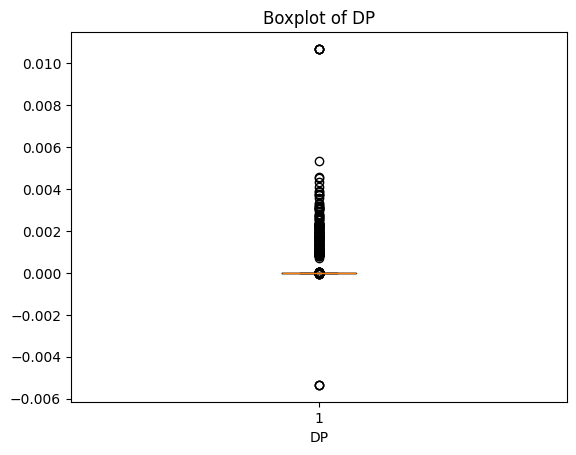

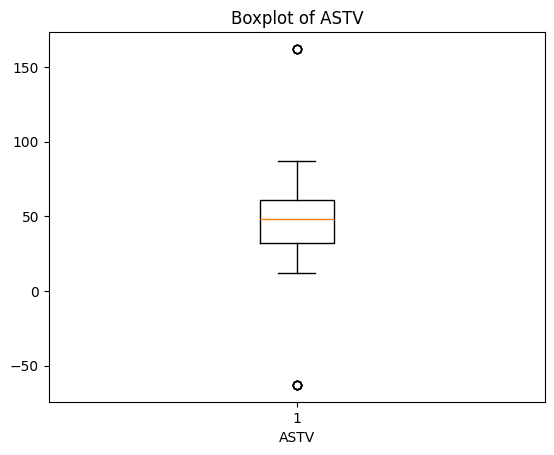

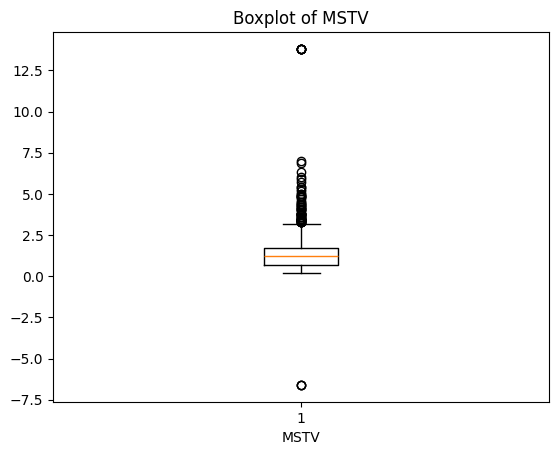

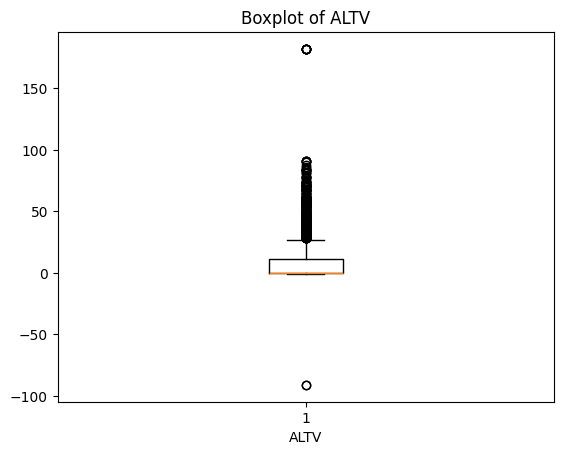

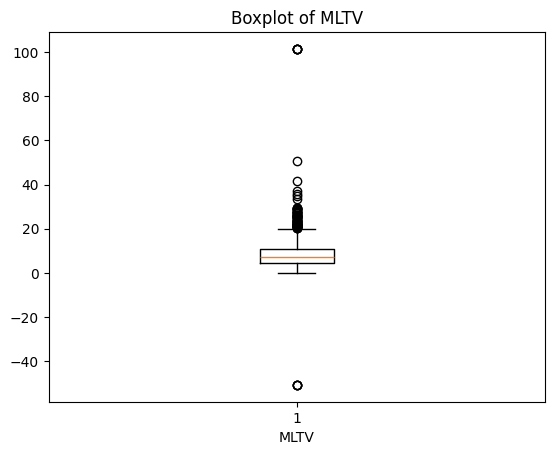

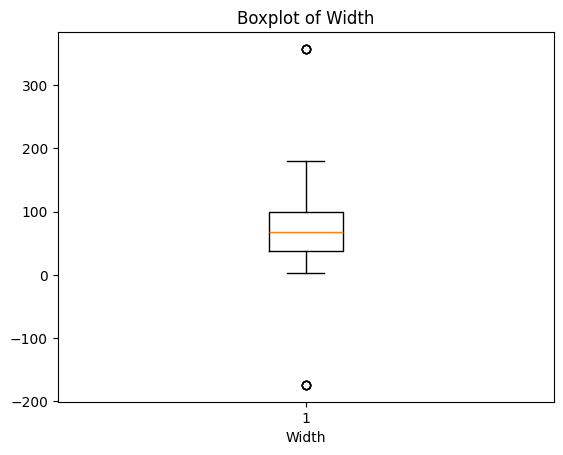

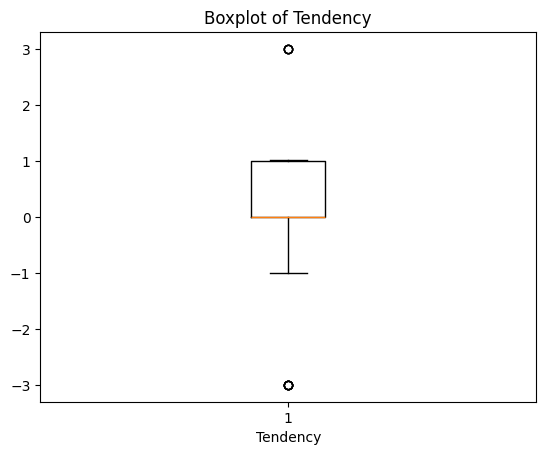

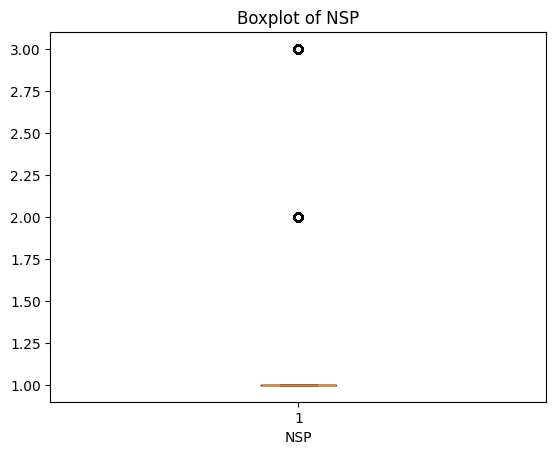

In [12]:
for col in df.select_dtypes(include=np.number).columns:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

Some variables contain outliers. In medical data, extreme values can represent real patient conditions. So, the outliers were kept to preserve the original data.

#### Distribution of Numerical Variables

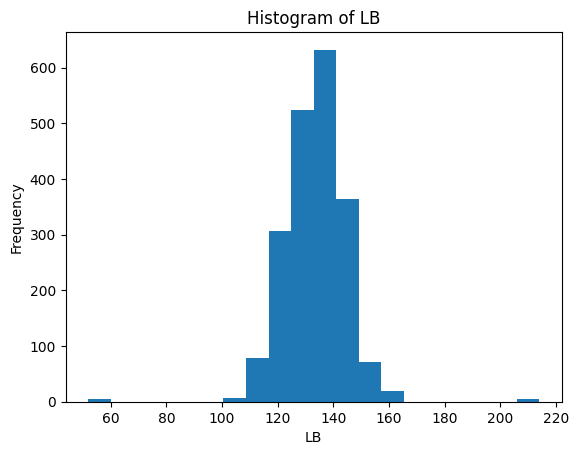

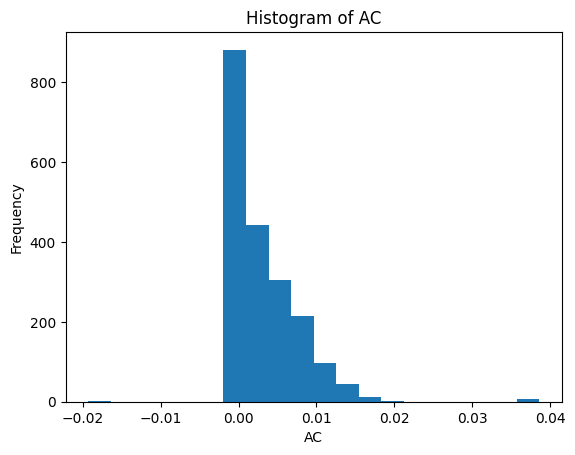

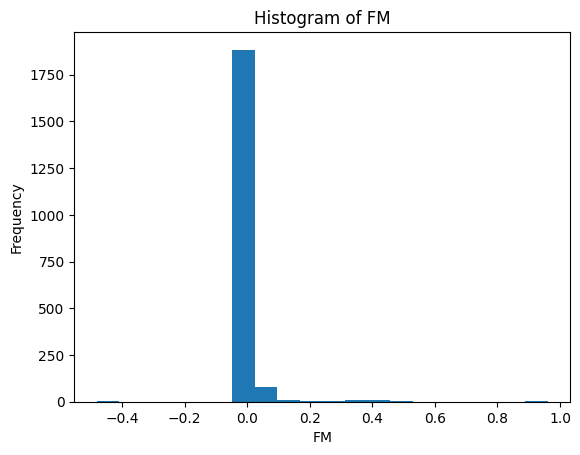

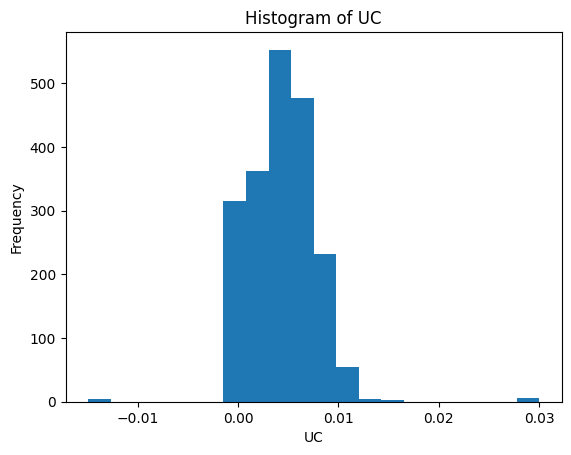

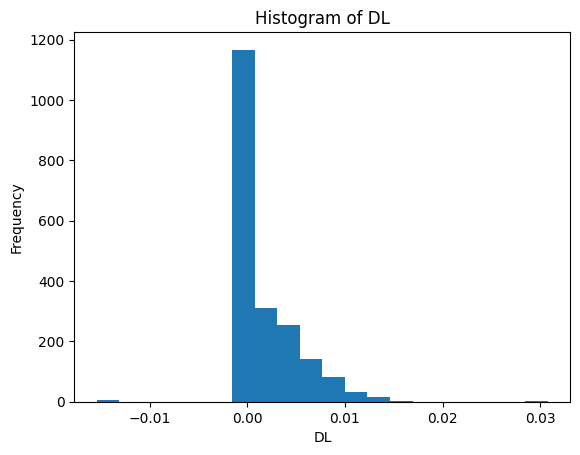

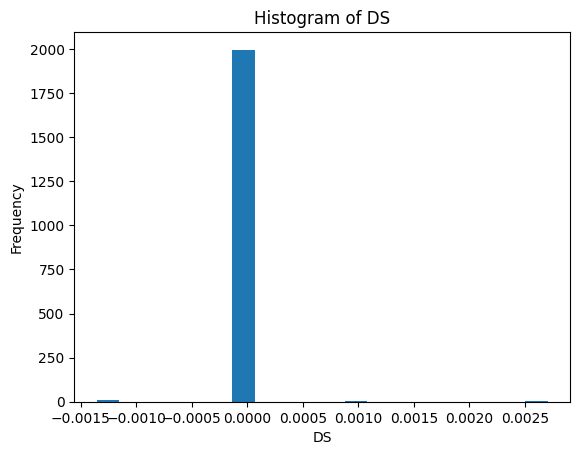

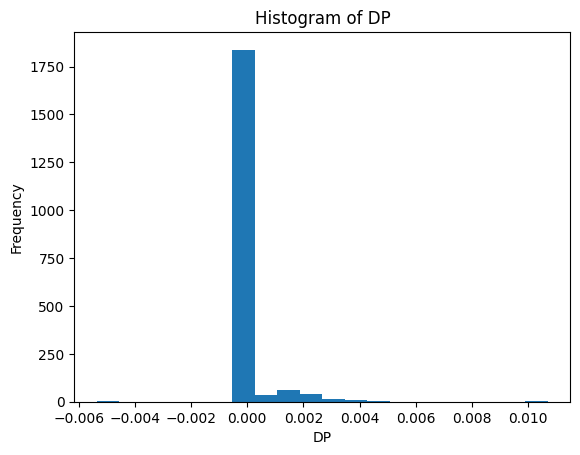

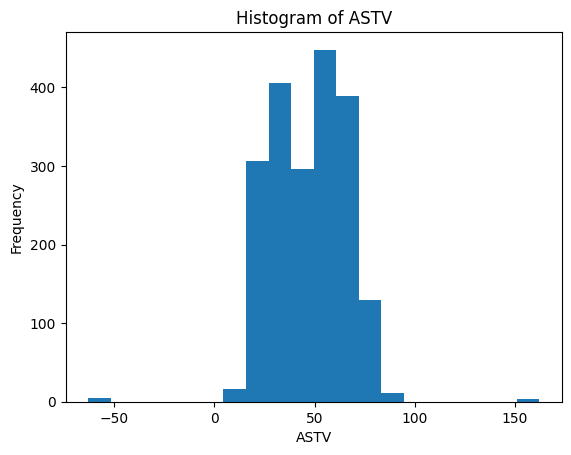

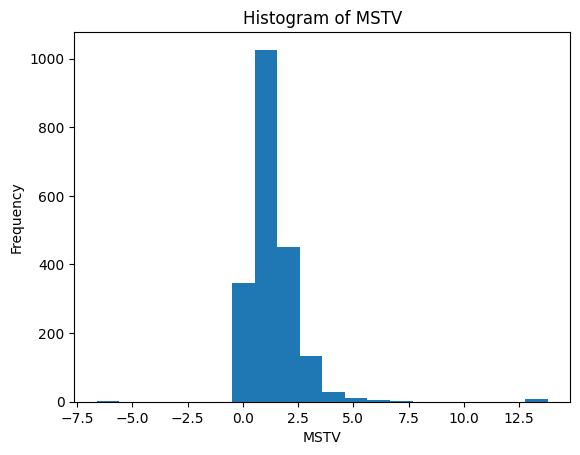

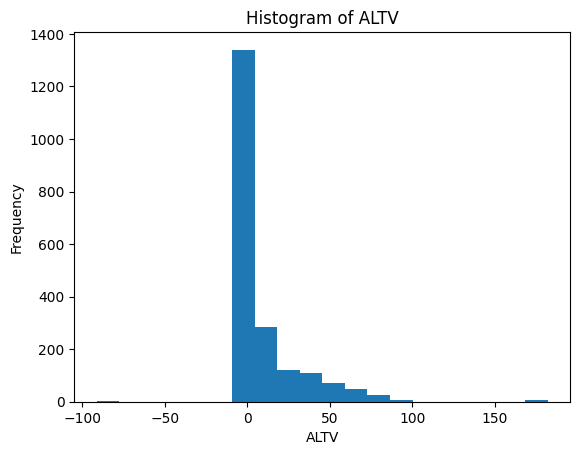

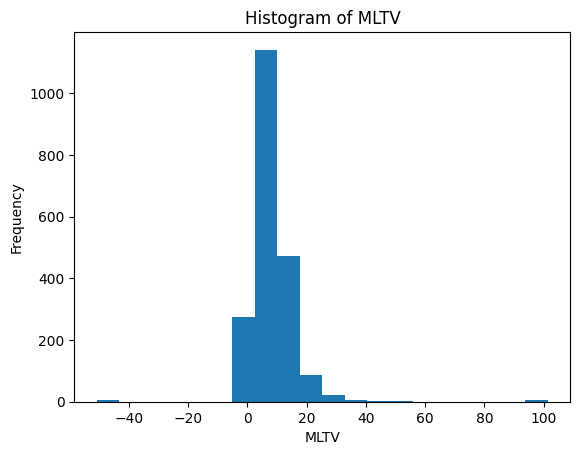

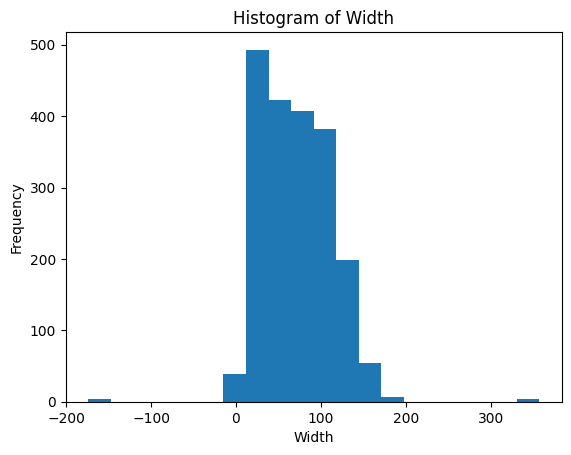

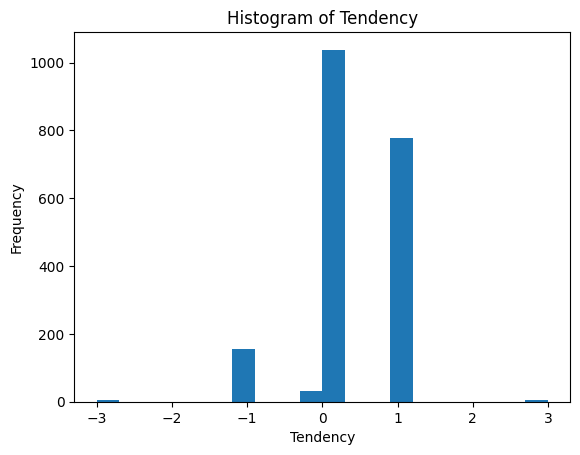

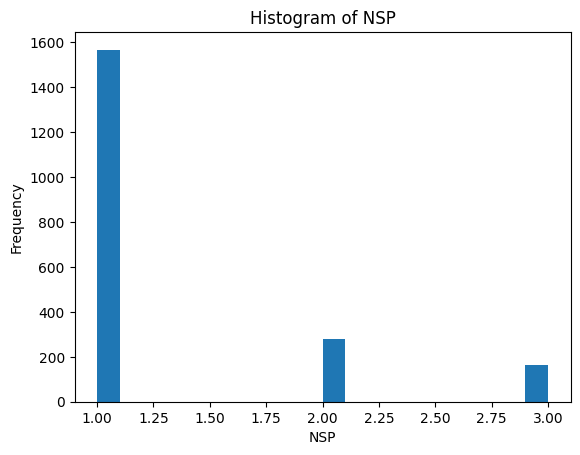

In [13]:

for col in df.select_dtypes(include=np.number).columns:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


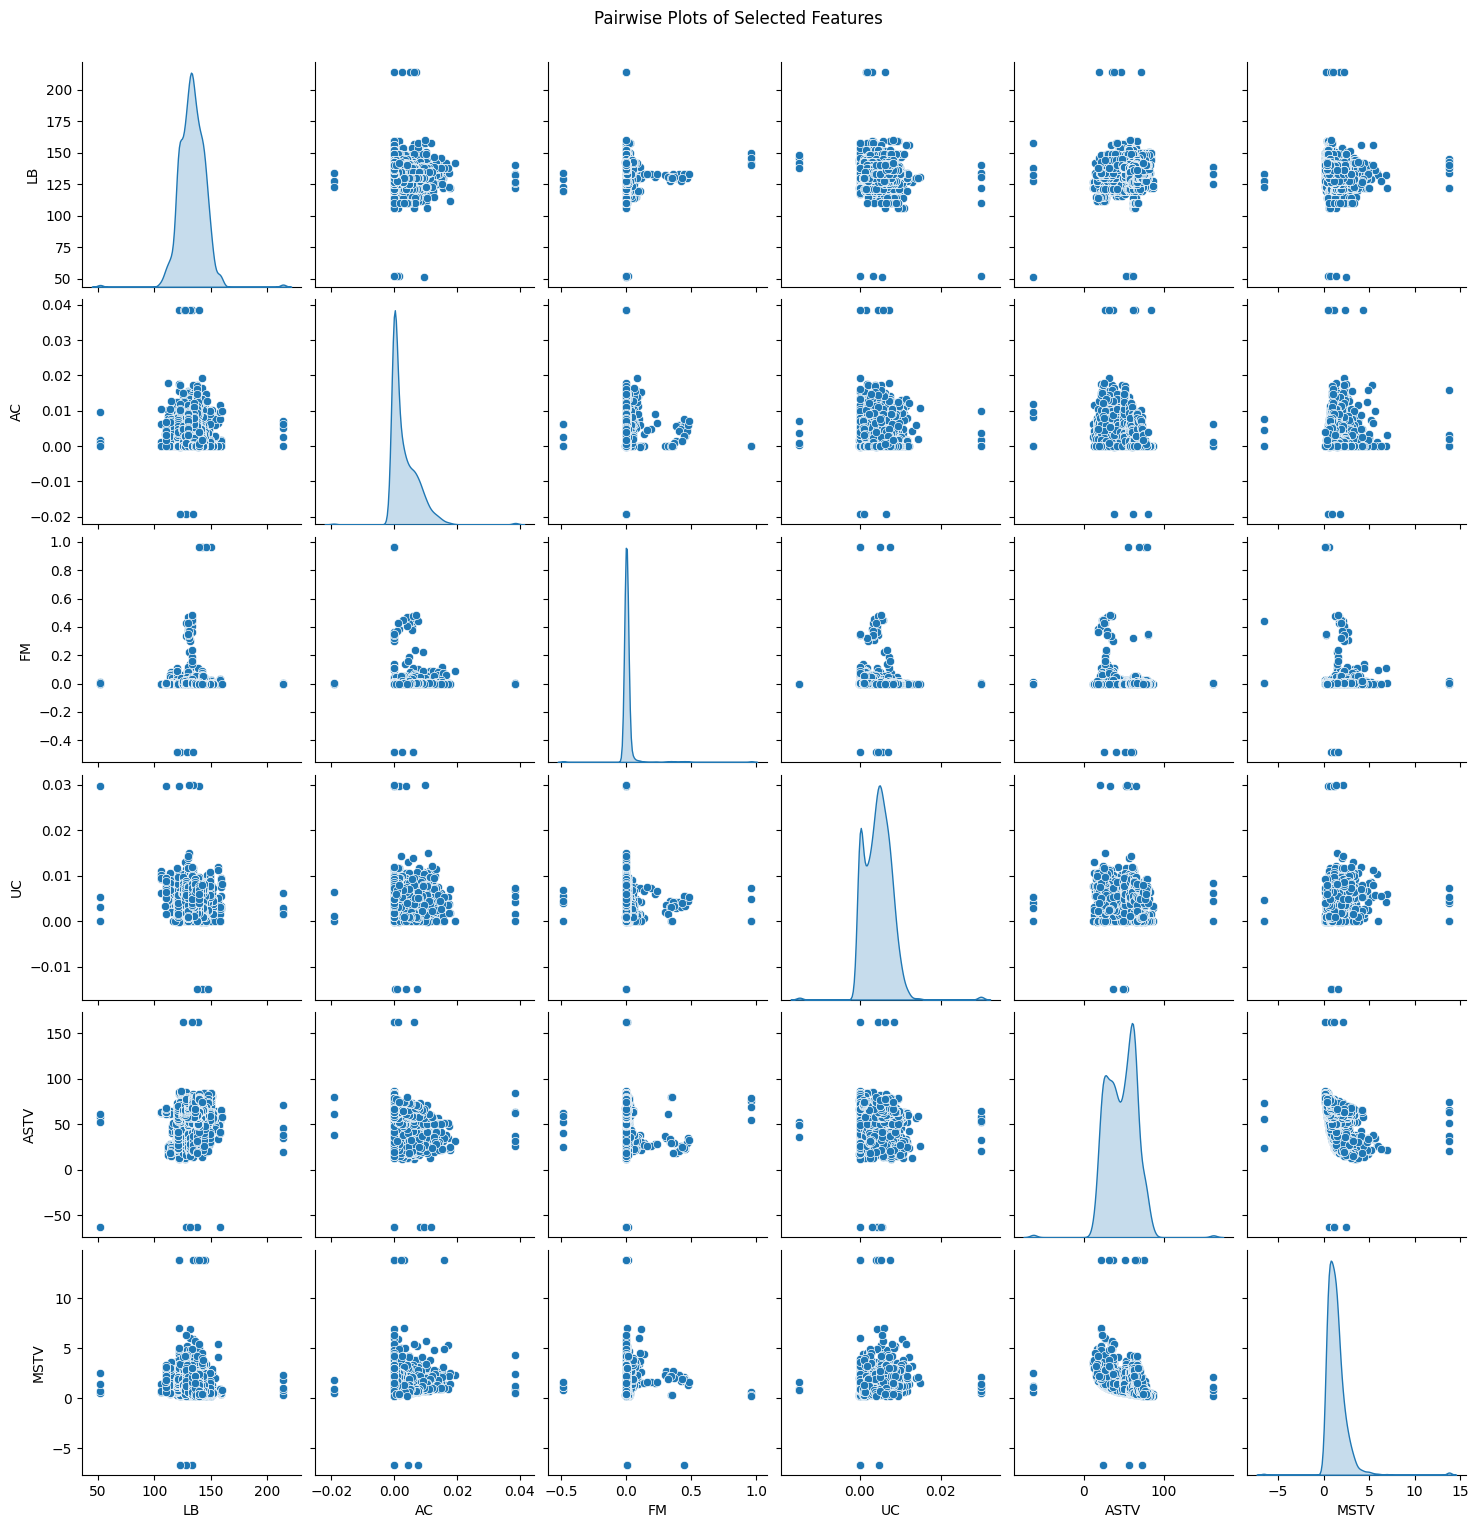

In [19]:
# Sample only if dataset is not too big
sns.pairplot(df[['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV']], diag_kind='kde')
plt.suptitle("Pairwise Plots of Selected Features", y=1.02)
plt.show()


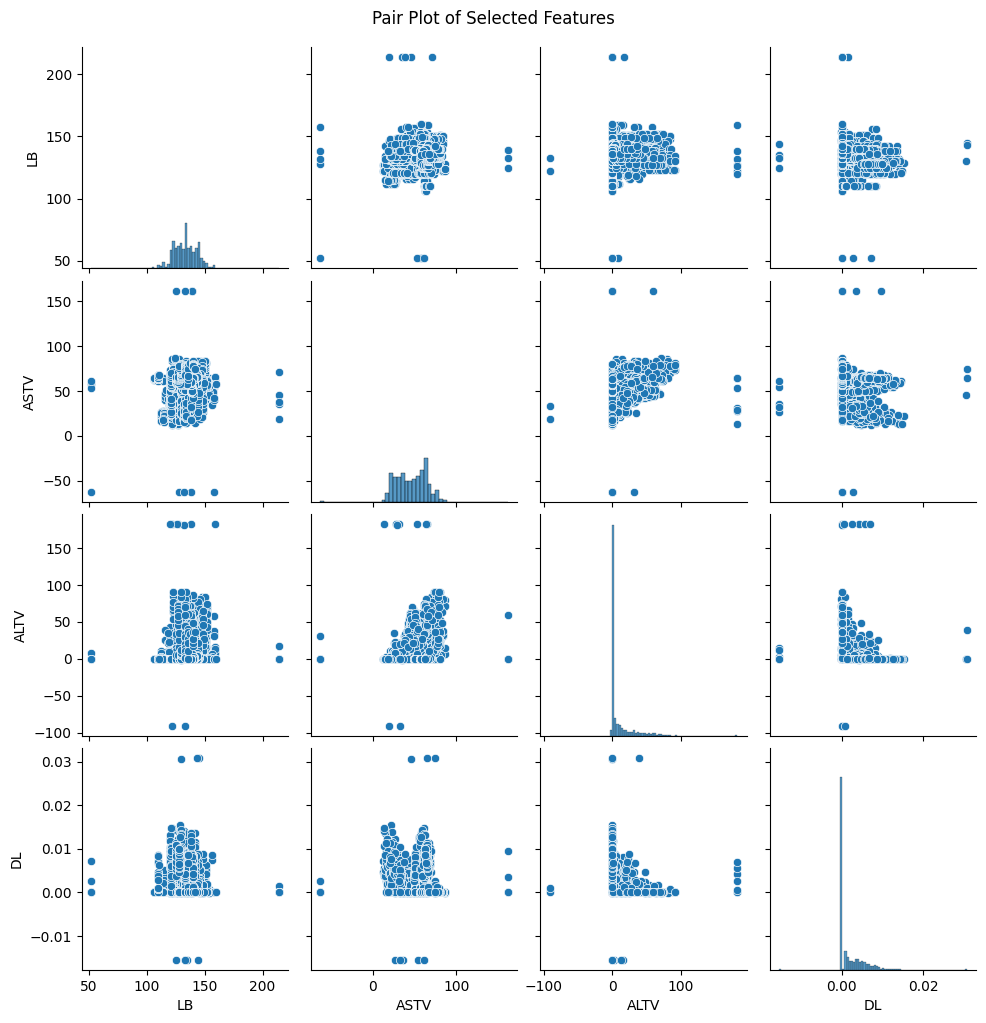

In [20]:
# Pair plot for selected key variables
sns.pairplot(df[['LB', 'ASTV', 'ALTV', 'DL']])
plt.suptitle('Pair Plot of Selected Features', y=1.02)
plt.show()

#### Fetal State (NSP) Distribution

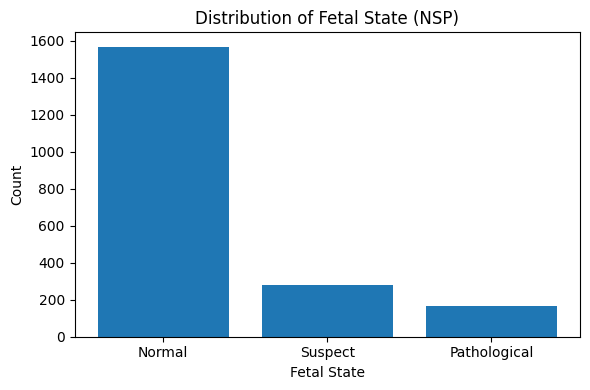

In [14]:
plt.figure(figsize=(6,4))

counts = df['NSP'].value_counts().sort_index()
labels = {1: "Normal", 2: "Suspect", 3: "Pathological"}
counts.index = counts.index.map(labels)

plt.bar(counts.index, counts.values)

plt.title("Distribution of Fetal State (NSP)")
plt.xlabel("Fetal State")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

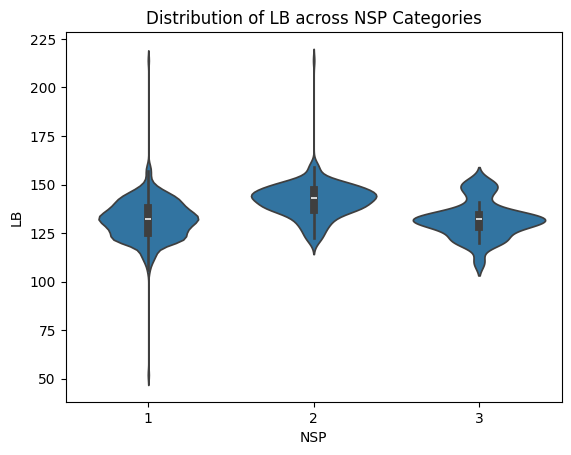

In [15]:
# Violin plot to see distribution of LB across NSP (assuming NSP is a category)
sns.violinplot(x='NSP', y='LB', data=df)
plt.title('Distribution of LB across NSP Categories')
plt.show()



The NSP variable represents fetal state classification. 
The distribution indicates class imbalance, which should be addressed before applying predictive models.


### Pattern Recognition & Insights

#### Correlation Analysis

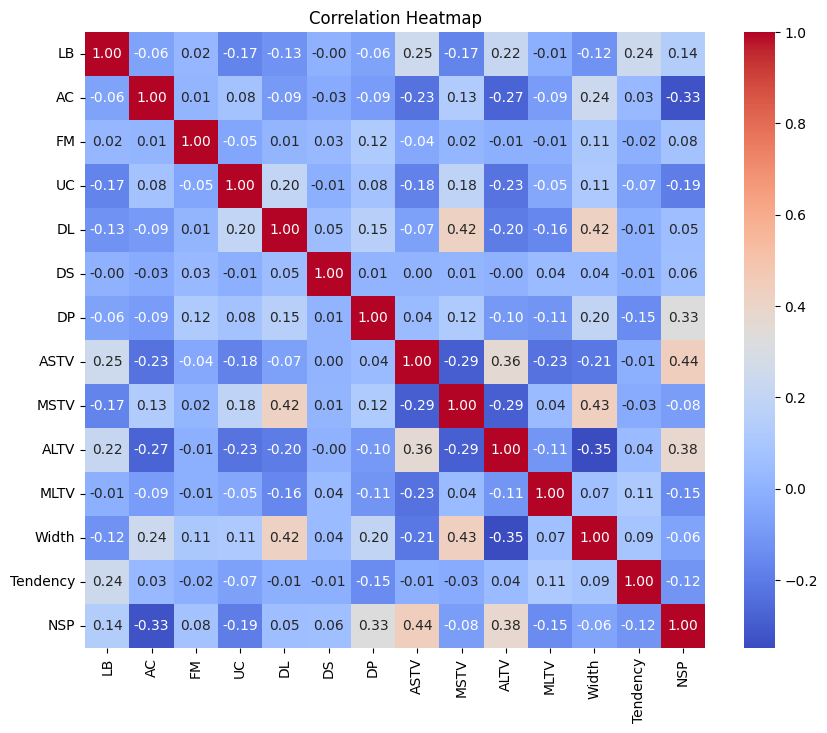

In [16]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")      

plt.title("Correlation Heatmap")
plt.show()


### Correlation Insights
- Most relationships are weak to moderate.
- Moderate correlations (~0.5–0.6) suggest meaningful but not strong associations.
- No extremely high (>0.8) correlations were observed, indicating low multicollinearity risk.


In [17]:
# Check if any column might represent time
df.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')

After inspecting the dataset, we found that there is no time-based column included. Because of this, we are not able to explore trends or changes in fetal measurements over time.


#### Key Insights

1. The dataset consists entirely of numerical cardiotocographic measurements.
2. Several variables exhibit skewed distributions, indicating non-normal behavior.
3. Outliers are present but likely clinically meaningful.
4. Moderate correlations exist between select variability and deceleration measures.
5. The fetal state (NSP) variable is imbalanced and may influence model performance.



# 5. Conclusion

- This exploratory analysis highlighted key features like ASTV, ALTV, and decelerations (DL, DS, DP) that are important in detecting abnormal fetal heart patterns.
- We found a strong positive correlation between ASTV and ALTV, and a negative relationship between decelerations and short-term variability, which may signal fetal distress.
- Outliers were addressed to reduce their effect, but the absence of time-related data limited analysis of trends over time.
- These findings provide a solid foundation for future work, such as building predictive models or incorporating time-based data to better understand fetal health changes.

